In [2]:
import os
import json
from typing import Literal
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np

In [ ]:
import os
import json
from typing import Literal
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np


class NeedleTraceImageFramesIndexDataset(Dataset):
    def __init__(
        self,
        root_dir,
        split=None,
        split_id=None,
        case_ids=None,
        cine_ids=None,
        needle_mask_fname="needle_mask_full.png",
        splits_file=None
    ):
        self.root_dir = root_dir

        if split is not None:
            splits_file = splits_file or os.path.join(root_dir, "splits.json")
            if not os.path.exists(splits_file):
                raise FileNotFoundError(f"Splits file not found: {splits_file}")
            with open(splits_file, "r") as f:
                splits_data = json.load(f)
            if split_id is None:
                split_id = list(splits_data.keys())[0]
            if split_id not in splits_data:
                raise ValueError(f"Split ID '{split_id}' not found in splits file.")
            if split not in splits_data[split_id]:
                raise ValueError(f"Split '{split}' not found in split ID '{split_id}'.")
            case_ids = splits_data[split_id][split]

        self.case_ids = case_ids
        self.cine_ids = cine_ids
        self.data = []

        # Traverse the directory structure to collect all cases and cine IDs
        for case_dir in os.listdir(root_dir):
            case_path = os.path.join(root_dir, case_dir)
            if not os.path.isdir(case_path):
                continue

            # Filter by case_ids if provided
            if case_ids and case_dir not in case_ids:
                continue

            for cine_id_dir in os.listdir(case_path):
                cine_path = os.path.join(case_path, cine_id_dir)
                if not os.path.isdir(cine_path):
                    continue

                # Filter by cine_ids if provided
                if cine_ids and cine_id_dir not in cine_ids:
                    continue

                image_path = os.path.join(cine_path, "image.png")
                needle_mask_path = os.path.join(cine_path, needle_mask_fname)
                info_path = os.path.join(cine_path, "info.json")

                if (
                    os.path.exists(image_path)
                    and os.path.exists(needle_mask_path)
                    and os.path.exists(info_path)
                ):

                    # Load metadata
                    with open(info_path, "r") as f:
                        info = json.load(f)

                    self.data.append(
                        {
                            "image_path": image_path,
                            "needle_mask_path": needle_mask_path,
                            "info_path": info_path,
                            "microsegnet_prostate_mask_path": os.path.join(
                                cine_path, "micro_seg_net_prostate_mask.png"
                            ),
                            "info": info,
                            "core_id": info["cine_id"],
                        }
                    )

    def __len__(self):
        """
        Returns the number of samples in the dataset.
        """
        return len(self.data)

    def __getitem__(self, idx):
        """
        Loads and returns a sample from the dataset.

        Args:
            idx (int): Index of the sample to retrieve.
        """
        return self.data[idx]


class NeedleTraceImageFramesDataset(Dataset):
    def __init__(
        self,
        root_dir,
        split=None,
        split_id=None,
        case_ids=None,
        cine_ids=None,
        transform=None,
        needle_mask_fname="needle_mask_full.png",
        out_fmt: Literal["pil", "np"] = "pil" #"np" #"pil", #Change back to pil after
    ):
        """
        PyTorch Dataset for loading needle annotation data.

        Args:
            root_dir (str): Path to the root directory containing exported data.
            case_ids (list, optional): List of case IDs to include. Defaults to None.
            cine_ids (list, optional): List of cine IDs to include. Defaults to None.
        """
        self.root_dir = root_dir

        if split is not None:
            splits_file = os.path.join(root_dir, "splits.json")
            if not os.path.exists(splits_file):
                raise FileNotFoundError(f"Splits file not found: {splits_file}")
            with open(splits_file, "r") as f:
                splits_data = json.load(f)
            if split_id is None:
                split_id = list(splits_data.keys())[0]
            if split_id not in splits_data:
                raise ValueError(f"Split ID '{split_id}' not found in splits file.")
            if split not in splits_data[split_id]:
                raise ValueError(f"Split '{split}' not found in split ID '{split_id}'.")
            case_ids = splits_data[split_id][split]

        self.case_ids = case_ids
        self.cine_ids = cine_ids
        self.transform = transform
        self.out_fmt = out_fmt
        self.data = []

        # Traverse the directory structure to collect all cases and cine IDs
        for case_dir in os.listdir(root_dir):
            case_path = os.path.join(root_dir, case_dir)
            if not os.path.isdir(case_path):
                continue

            # Filter by case_ids if provided
            if case_ids and case_dir not in case_ids:
                continue

            for cine_id_dir in os.listdir(case_path):
                cine_path = os.path.join(case_path, cine_id_dir)
                if not os.path.isdir(cine_path):
                    continue

                # Filter by cine_ids if provided
                if cine_ids and cine_id_dir not in cine_ids:
                    continue

                if self.root_dir == '/datasets/exactvu_pca/OPTIMUM/UA_OL_PU_annotated_needles_multiframe':
                    frames_path = os.path.join(cine_path, "frames")
                    image_path = os.path.join(frames_path,'0000.png' )
                else:
                    image_path = os.path.join(cine_path, "image.png")

                needle_mask_path = os.path.join(cine_path, needle_mask_fname)
                info_path = os.path.join(cine_path, "info.json")

                if (
                    os.path.exists(image_path)
                    and os.path.exists(needle_mask_path)
                    and os.path.exists(info_path)
                ):

                    # Load metadata
                    with open(info_path, "r") as f:
                        info = json.load(f)

                    self.data.append(
                        {
                            "image_path": image_path,
                            "needle_mask_path": needle_mask_path,
                            "info_path": info_path,
                            "microsegnet_prostate_mask_path": os.path.join(
                                cine_path, "micro_seg_net_prostate_mask.png"
                            ),
                            "info": info,
                        }
                    )

    def __len__(self):
        """
        Returns the number of samples in the dataset.
        """
        return len(self.data)

    def __getitem__(self, idx):
        """
        Loads and returns a sample from the dataset.

        Args:
            idx (int): Index of the sample to retrieve.

        Returns:
            dict: A dictionary containing the image, needle mask, and metadata.
        """
        sample = self.data[idx]

        # Load image
        image = Image.open(sample["image_path"]).convert("RGB")
        if self.out_fmt == "np":
            image = np.array(image)

        # Load needle mask
        needle_mask = Image.open(sample["needle_mask_path"]).convert("L")
        if self.out_fmt == "np":
            needle_mask = np.array(needle_mask)

        # Load metadata
        info = sample["info"]

        out = {
            "image": image,
            "needle_mask": needle_mask,
            "path": sample["image_path"],
            "info": info,
        }
        if os.path.exists(sample["microsegnet_prostate_mask_path"]):
            microsegnet_prostate_mask = Image.open(
                sample["microsegnet_prostate_mask_path"]
            ).convert("L")
            if self.out_fmt == "np":
                microsegnet_prostate_mask = np.array(microsegnet_prostate_mask)
            out["prostate_mask"] = microsegnet_prostate_mask
            # dummy = np.array(microsegnet_prostate_mask)
            # print(np.unique(dummy))
        #     print("YES")
        # else:
        #     print("NO")
        #     print(sample["microsegnet_prostate_mask_path"])

        # Apply transformations if specified
        if self.transform:
            out = self.transform(out)

        return out

    def list_indices_by_patient_ids(self):
        # get all patient ids:

        outputs = {}

        for index, sample in enumerate(self.data):
            info = sample["info"]
            case_id = info["case"]
            core_id = info["cine_id"]

            outputs.setdefault(case_id, []).append((index, core_id))

        for case_id, index_info in outputs.items():
            indices_sorted = [
                index_info_i[0]
                for index_info_i in sorted(index_info, key=lambda item: item[1])
            ]
            outputs[case_id] = indices_sorted

        return outputs


In [7]:
if __name__ == "__main__":
    # Initialize the dataset with specific case_ids or cine_ids
    dataset = NeedleTraceImageFramesDataset(
        # root_dir="/datasets/exactvu_pca/OPTIMUM/UA_OL_PU_annotated_needles_multiframe"
        root_dir="/datasets/exactvu_pca/OPTIMUM/UA_annotated_needles"
    )
    print(len(dataset))

    # Access a sample
    sample = dataset[0]
    print(sample["info"])  # Print metadata
    print(sample["image"].size)  # Print image size
    print(sample["needle_mask"].size)  # Print needle mask size
    # Display the sample
    # sample["image"].show()  # Display the image
    # sample["needle_mask"].show()  # Display the needle mask

1118
{'cine_id': 'UA-003-005', 'center': 'UA', 'case': 'UA-003', 'isBiopsy': True, 'isFusionVu': False, 'hasFusionVuOverlay': False, 'bimg_path': '/Users/pwilson/Library/CloudStorage/Box-Box/OPTIMUM Blinded Database/UA/UA-003/20220411070223104/20220411070223151/20220411073416826/212359587264577227749774183747562.bimg', 'cine_number': 5.0, 'length': 60.0, 'heightMm': 28.0, 'heightPixel': 962.0, 'widthMm': 46.08, 'widthPixel': 1372.0, 'createdDate': '2022-04-11T14:11:29.0Z', 'Sample ID': '1.1', 'Cine #': '5', 'PRI-MUS': '5', 'PI-RADS': nan, 'Notes': nan, 'Number of Samples': 1.0, 'Core Length': '18', 'Diagnosis': 'Carcinoma', 'GG': 1.0, '% Cancer': 50.0, '% P4': nan, 'P Inv': True, 'IDC': False, 'Cribiform': False, 'Inflamm': False, 'HGPIN': False, 'Atypia': False, 'PATH Notes': 'RB; Overall % Pattern 4 is 15.', 'PATH ID': '1.1', 'case_path': 'UA-003', 'age': 64.0, 'psa': 11.5, 'study_arm': 'Arm3-MicroUS-MRI'}
(1372, 833)
(1372, 833)


In [4]:
from IPython.display import display

In [12]:
import matplotlib.pyplot as plt

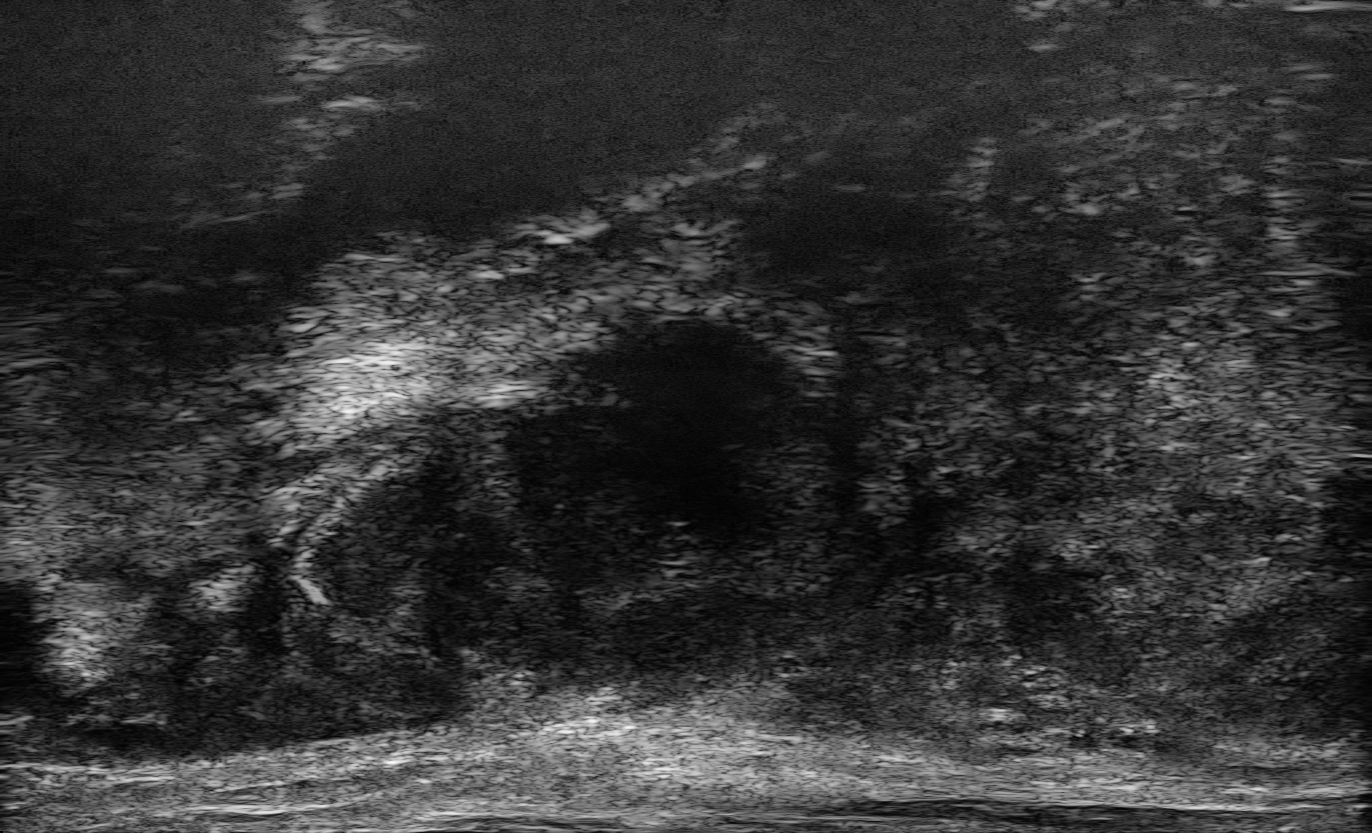

In [5]:
display(sample["image"]) # Display the image
# sample["needle_mask"].show()

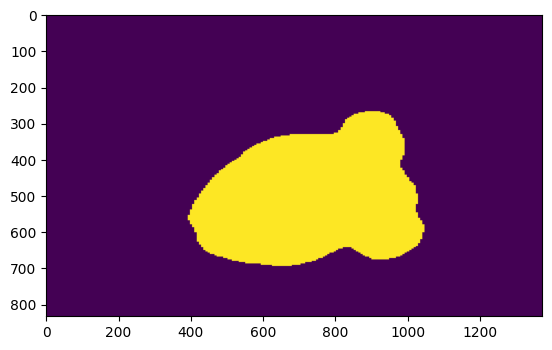

In [13]:
plt.imshow(sample["microsegnet_prostate_mask"])

In [ ]:
dir = root/folder/folder/mask.png

In [17]:
img_p = Image.open('/datasets/exactvu_pca/OPTIMUM/UA_OL_PU_annotated_needles_multiframe/OL-004/OL-004-005/micro_seg_net_prostate_mask.png')

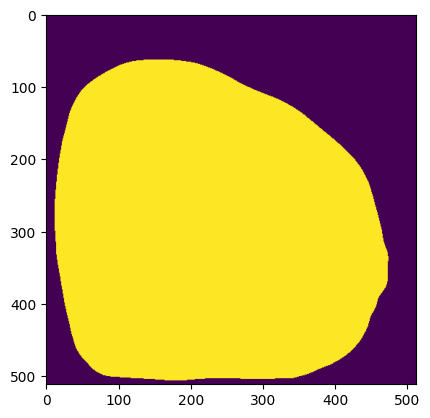

In [18]:
plt.imshow(img_p)

In [15]:
img = Image.open('/home/obed/projects/aip-medilab/shared/Guo-Obed-prostatemasks-2026Jun8/OL/OL-004-018/mask.png')

In [19]:
img.size

(1372, 833)

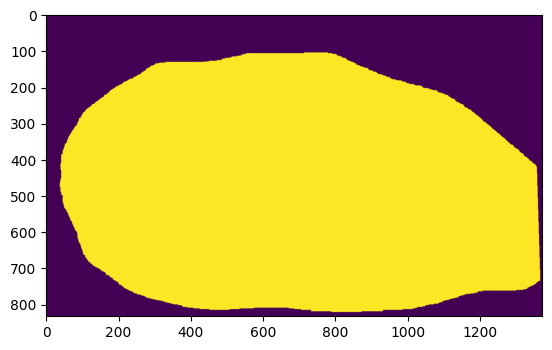

In [16]:
plt.imshow(img)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import numpy as np


class FrozenSegmentationModel(nn.Module):
    """
    Wrapper for pre-trained MicroSegNet segmentation model.
    Handles batch processing and returns segmentation masks.
    """
    
    def __init__(self, checkpoint_path='MicroSegNet.pth', img_size=224, 
                 n_skip=3, vit_name='R50-ViT-B_16', vit_patches_size=16, 
                 num_classes=1, device='cuda'):
        super().__init__()
        
        self.img_size = img_size
        self.device = device
        
        # Initialize model
        from vit_seg_modeling import CONFIGS as CONFIGS_ViT_seg
        from vit_seg_modeling import VisionTransformer as ViT_seg
        
        config_vit = CONFIGS_ViT_seg[vit_name]
        config_vit.n_classes = num_classes
        config_vit.n_skip = n_skip
        config_vit.patches.size = (vit_patches_size, vit_patches_size)
        
        if vit_name.find('R50') != -1:
            config_vit.patches.grid = (
                int(img_size / vit_patches_size), 
                int(img_size / vit_patches_size)
            )
        
        self.net = ViT_seg(
            config_vit, 
            img_size=img_size, 
            num_classes=config_vit.n_classes
        ).to(device)
        
        # Load pre-trained weights
        self.net.load_state_dict(torch.load(checkpoint_path, map_location=device))
        self.net.eval()
        
        # Freeze all parameters
        for param in self.net.parameters():
            param.requires_grad = False
    
    def forward(self, images):
        """
        Forward pass for batch of images.
        
        Args:
            images: torch.Tensor of shape [B, C, H, W]
                   - B: batch size
                   - C: channels (1 for grayscale, 3 for RGB)
                   - H, W: height and width
        
        Returns:
            seg_masks: torch.Tensor of shape [B, 1, H, W]
                      Binary segmentation masks (logits, not probabilities)
        """
        B, C, H_orig, W_orig = images.shape
        
        # Normalize to [0, 1] if not already
        if images.max() > 1.0:
            images = images / 255.0
        
        # Convert to grayscale if RGB
        if C == 3:
            # Convert RGB to grayscale: 0.299*R + 0.587*G + 0.114*B
            images = (
                0.299 * images[:, 0:1, :, :] + 
                0.587 * images[:, 1:2, :, :] + 
                0.114 * images[:, 2:3, :, :]
            )
        
        # Resize to model's expected input size
        if (H_orig, W_orig) != (self.img_size, self.img_size):
            images_resized = F.interpolate(
                images,
                size=(self.img_size, self.img_size),
                mode='bilinear',
                align_corners=False
            )
        else:
            images_resized = images
        
        # Forward pass through network
        with torch.no_grad():
            outputs, _, _, _ = self.net(images_resized)  # [B, 1, img_size, img_size]
        
        # Resize predictions back to original size
        if (H_orig, W_orig) != (self.img_size, self.img_size):
            seg_masks = F.interpolate(
                outputs,
                size=(H_orig, W_orig),
                mode='bilinear',
                align_corners=False
            )
        else:
            seg_masks = outputs
        
        return seg_masks  # Return logits [B, 1, H, W]
    
    def predict_batch(self, batch_dict):
        """
        Predict segmentation masks for a batch dictionary.
        
        Args:
            batch_dict: Dictionary containing 'bmode' key with images
                       Expected shape: [B, C, H, W] as torch.Tensor
        
        Returns:
            seg_masks: torch.Tensor [B, 1, H, W] - segmentation logits
            seg_probs: torch.Tensor [B, 1, H, W] - segmentation probabilities
            seg_binary: torch.Tensor [B, 1, H, W] - binary masks (0 or 1)
        """
        images = batch_dict['bmode'].to(self.device)
        
        # Get logits
        seg_logits = self.forward(images)
        
        # Convert to probabilities
        seg_probs = torch.sigmoid(seg_logits)
        
        # Convert to binary (threshold at 0.5)
        seg_binary = (seg_probs > 0.5).float()
        
        return seg_logits, seg_probs, seg_binary
    
    def __call__(self, x):
        """
        Allow model(x) syntax.
        
        Args:
            x: Either torch.Tensor [B, C, H, W] or dict with 'bmode' key
        
        Returns:
            seg_masks: torch.Tensor [B, 1, H, W] - segmentation logits
        """
        if isinstance(x, dict):
            return self.predict_batch(x)[0]  # Return logits
        else:
            return self.forward(x)

In [2]:
frozen_segnet = FrozenSegmentationModel(
    checkpoint_path='/datasets/exactvu_pca/checkpoint_store/Paul/medAI/MicroSegNet.pth',
    img_size=224,
    device='cuda'
)

In [3]:
import os

os.environ["EXACTVU_PCA_DATA_ROOT"] = "/datasets/exactvu_pca"
os.environ['NCT_RAW_DATA_DIR']='/datasets/exactvu_pca/nct2013'
os.environ['NCT_METADATA_PATH']='/datasets/exactvu_pca/nct2013/metadata.csv'

from projects.seg_ttt.dataloader_ttt import get_dataloaders_from_args
from omegaconf import OmegaConf

/home/obed/projects/aip-medilab/obed/medproj/medAI/med_env/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/obed/projects/aip-medilab/obed/medproj/medAI/med_env/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metad

In [4]:
config_path = "/project/6106383/obed/medproj/medAI/projects/seg_ttt/antta_cfg/test_ol_cfg_ttt.yaml"
cfg = OmegaConf.load(config_path)

loaders = get_dataloaders_from_args(cfg.data)
# train_loader = loaders["train"]
val_loader = loaders["val"]

Train cores: 5479
Validation cores: 0
Test cores: 0


Loading dataset: 100%|██████████| 5479/5479 [00:00<00:00, 2310303.77it/s]
/home/obed/projects/aip-medilab/obed/medproj/medAI/med_env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [5]:
img = next(iter(val_loader))

In [7]:
img['bmode_raw'].shape

torch.Size([1, 833, 1372])

In [9]:
a = img['bmode_raw']

In [14]:
a.shape

torch.Size([1, 833, 1372])

In [12]:
b=a.unsqueeze(dim=0)

In [13]:
b.shape

torch.Size([1, 1, 833, 1372])

In [5]:
for train_iter, data in enumerate(val_loader):
    images = data['bmode'].to('cuda') 
    print(data['bmode'].shape)
    print(train_iter)
    print(2)
    # if train_iter == 2:
    #     break
    

In [5]:
len(val_loader)

569

In [12]:
images.size()

NameError: name 'images' is not defined

In [7]:
img = next(iter(val_loader))

/home/obed/projects/aip-medilab/obed/medproj/medAI/med_env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


StopIteration: 

In [21]:
import os
import numpy as np
from PIL import Image

root_path = '/datasets/exactvu_pca/OPTIMUM/UA_OL_PU_annotated_needles_multiframe'

for train_iter, data in enumerate(val_loader):
    imgs = data['bmode_raw'].to('cuda')   # [B, C, H, W]
    images = imgs.unsqueeze(dim=0)
    patient_paths = data['patient_id']
    core_paths = data['core_id']

    seg_logits = frozen_segnet(images)          # [B, 1, H, W]
    seg_probs = torch.sigmoid(seg_logits)
    seg_masks = (seg_probs > 0.5).float()       # [B, 1, H, W]

    B = seg_masks.shape[0]

    # if train_iter == 2:
    #     break

    for i in range(B):
        mask = seg_masks[i, 0].detach().cpu().numpy()
        mask_img = (mask * 255).astype(np.uint8)

        # Safe string conversion
        patient_id = str(patient_paths[i])
        core_id = str(core_paths[i])

        # Build paths
        patient_path = os.path.join(root_path, patient_id)
        core_path = os.path.join(patient_path, core_id)

        # Ensure directory exists
        os.makedirs(core_path, exist_ok=True)

        # Save
        save_path = os.path.join(core_path, "micro_seg_net_prostate_mask.png")
        # print(save_path)
        Image.fromarray(mask_img).save(save_path)
    

/home/obed/projects/aip-medilab/obed/medproj/medAI/med_env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


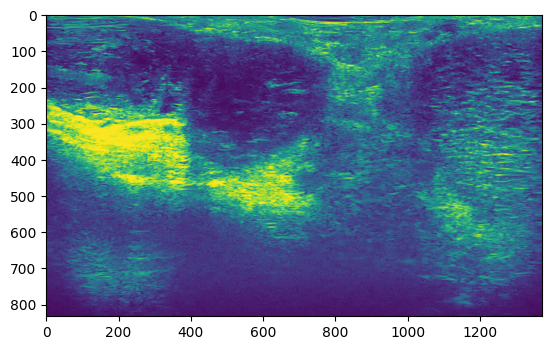

In [19]:
plt.imshow(imgs.detach().cpu().numpy()[0])

In [20]:
seg_masks.shape

torch.Size([1, 1, 833, 1372])

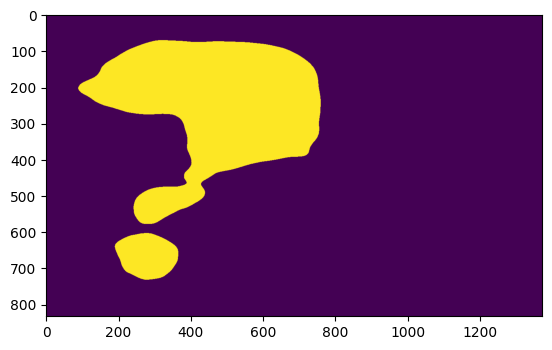

In [18]:
import matplotlib.pyplot as plt
plt.imshow(seg_masks.detach().cpu().numpy()[0,0,])

In [45]:
# ── main evaluation ────────────────────────────────────────────────────────────
from PIL import Image
from torch.utils.data import Dataset
import json
from typing import Literal
import pandas as pd
from tqdm import tqdm


# ── helpers ────────────────────────────────────────────────────────────────────

def load_mask_as_binary(path: str) -> np.ndarray:
    img = Image.open(path)
    arr = np.array(img, dtype=np.uint8).copy()
    binary = (arr > 0).astype(np.uint8)
    # Temporary sanity check — remove once confirmed working
    print(f"  [load_mask_as_binary] path={path}")
    print(f"  [load_mask_as_binary] unique={np.unique(arr)}, sum_before={arr.sum()}, sum_after={binary.sum()}")
    return binary


def dice_score(pred: np.ndarray, gt: np.ndarray) -> float:
    """Compute Dice coefficient between two binary masks."""
    intersection = (pred & gt).sum()
    total = pred.sum() + gt.sum()
    if total == 0:
        return 1.0  # both empty → perfect agreement
    return 2.0 * intersection / total


def evaluate_dice(
    root_dir: str,
    gt_root_dir: str,                          # ← separate root for GT masks
    gt_mask_fname: str = "mask.png",           # filename inside cine_id folder
    split: str = None,
    split_id: str = None,
    case_ids: list = None,
    cine_ids: list = None,
    needle_mask_fname: str = "needle_mask.png",
    OL: bool = False,
) -> pd.DataFrame:
    """
    Compute per-sample Dice scores.

    Parameters
    ----------
    root_dir        : dataset root (for predicted masks)
    gt_root_dir     : separate root where GT masks live.
                      Expected structure: gt_root_dir / case_id / cine_id / mask.png
    gt_mask_fname   : filename of the GT mask inside each cine_id folder
    """

    if OL:
        case_ids = [
            p
            for p in os.listdir(root_dir)
            if p[:2]=='OL'
        ]
        print(case_ids)
        
    if not OL:
        ds = NeedleTraceImageFramesDataset(
            root_dir=root_dir,
            split=split,
            split_id=split_id,
            case_ids=case_ids,
            cine_ids=cine_ids,
            needle_mask_fname=needle_mask_fname,
            out_fmt="np",
        )
    else:
        ds = NeedleTraceImageFramesDataset(
            root_dir=root_dir,
            case_ids = case_ids,
            needle_mask_fname=needle_mask_fname,
            out_fmt="np",
        )

    print(len(ds))

    records = []

    for idx in tqdm(range(len(ds)), desc="Evaluating"):
        raw = ds.data[idx]
        info = raw["info"]

        case_id = info.get("case")
        cine_id = info.get("cine_id")

        # ── ground truth: gt_root_dir / case_id / cine_id / mask.png ──────────
        gt_path = os.path.join(gt_root_dir, cine_id, gt_mask_fname)
        if not os.path.exists(gt_path):
            print(f"[WARN] GT mask not found, skipping: {gt_path}")
            continue

        gt_mask = load_mask_as_binary(gt_path)

        # ── prediction ────────────────────────────────────────────────────────
        pred_path = raw["microsegnet_prostate_mask_path"]
        if not os.path.exists(pred_path):
            print(f"[WARN] Predicted mask not found, skipping: {pred_path}")
            continue

        pred_mask = load_mask_as_binary(pred_path)

        # ── resize pred to GT space if shapes differ ──────────────────────────
        if pred_mask.shape != gt_mask.shape:
            pred_pil = Image.fromarray(pred_mask * 255).resize(
                (gt_mask.shape[1], gt_mask.shape[0]), Image.NEAREST
            )
            pred_mask = (np.array(pred_pil) > 127).astype(np.uint8)

        # ── Dice ──────────────────────────────────────────────────────────────
        score = dice_score(pred_mask, gt_mask)

        records.append(
            {
                "case_id":   case_id,
                "cine_id":   cine_id,
                "gt_path":   gt_path,
                "pred_path": pred_path,
                "dice":      round(score, 4),
            }
        )

    df = pd.DataFrame(records)

    if not df.empty:
        print(f"\n{'─'*45}")
        print(f"  Samples evaluated : {len(df)}")
        print(f"  Mean Dice         : {df['dice'].mean():.4f}")
        print(f"  Median Dice       : {df['dice'].median():.4f}")
        print(f"  Std Dice          : {df['dice'].std():.4f}")
        print(f"  Min Dice          : {df['dice'].min():.4f}")
        print(f"  Max Dice          : {df['dice'].max():.4f}")
        print(f"{'─'*45}\n")
    else:
        print("No valid samples found.")

    return df


In [ ]:
def debug_single_sample(
    root_dir: str,
    gt_root_dir: str,
    gt_mask_fname: str = "mask.png",
    needle_mask_fname: str = "needle_mask.png",
    idx: int = 0,
):
    ds = NeedleTraceImageFramesDataset(
        root_dir=root_dir,
        needle_mask_fname=needle_mask_fname,
        out_fmt="np",
    )

    raw = ds.data[idx]
    info = raw["info"]
    case_id = info.get("case")
    cine_id = info.get("cine_id")

    print(f"case_id : {case_id}")
    print(f"cine_id : {cine_id}")

    # ── GT ────────────────────────────────────────────────────────────────────
    gt_path = os.path.join(gt_root_dir, cine_id, gt_mask_fname)
    print(f"\nGT path  : {gt_path}")
    print(f"GT exists: {os.path.exists(gt_path)}")

    gt_img = Image.open(gt_path).convert("L")
    gt_arr = np.array(gt_img)
    print(f"GT shape : {gt_arr.shape}")
    print(f"GT dtype : {gt_arr.dtype}")
    print(f"GT unique values : {np.unique(gt_arr)}")
    print(f"GT min/max       : {gt_arr.min()} / {gt_arr.max()}")

    gt_mask = (gt_arr > 127).astype(np.uint8)
    print(f"GT binary sum (# foreground px): {gt_mask.sum()}")

    # ── Pred ──────────────────────────────────────────────────────────────────
    pred_path = raw["microsegnet_prostate_mask_path"]
    print(f"\nPred path  : {pred_path}")
    print(f"Pred exists: {os.path.exists(pred_path)}")

    # pred_img = Image.open(pred_path).convert("L")
    # pred_arr = np.array(pred_img)
    # print(f"Pred shape : {pred_arr.shape}")
    # print(f"Pred dtype : {pred_arr.dtype}")
    # print(f"Pred unique values : {np.unique(pred_arr)}")
    # print(f"Pred min/max       : {pred_arr.min()} / {pred_arr.max()}")

    # pred_img = Image.open(pred_path)
    # print(f"Pred mode: {pred_img.mode}")  # might be 'P' (palette) or 'RGBA'
    # pred_arr = np.array(pred_img)
    # print(f"Pred raw shape  : {pred_arr.shape}")
    # print(f"Pred raw unique : {np.unique(pred_arr)}")

    pred_img = Image.open(pred_path)
    pred_arr = np.array(pred_img)

    print(f"np.unique: {np.unique(pred_arr)}")
    print(f"(pred_arr == 1).sum(): {(pred_arr == 1).sum()}")  # count exact 1s
    print(f"(pred_arr > 0).sum(): {(pred_arr > 0).sum()}")    # should match above

    pred_mask = (pred_arr == 1).astype(np.uint8)
    print(f"pred_mask.sum(): {pred_mask.sum()}")

    print(f"pred_arr.dtype: {pred_arr.dtype}")
    print(f"pred_arr.flags: {pred_arr.flags}")
    # Force a clean copy
    pred_arr_copy = np.array(pred_img, dtype=np.uint8).copy()
    print(f"copy unique: {np.unique(pred_arr_copy)}")
    print(f"copy > 0 sum: {(pred_arr_copy > 0).sum()}")

    print(pred_arr.flat[:20])   # print first 20 raw values
    print(pred_arr[pred_arr > 0][:10])  # print first 10 non-zero values if any

    pred_mask = (pred_arr > 127).astype(np.uint8)
    print(f"Pred binary sum (# foreground px): {pred_mask.sum()}")

    # ── Shape alignment ───────────────────────────────────────────────────────
    print(f"\nShapes match: {pred_arr.shape == gt_arr.shape}")
    if pred_arr.shape != gt_arr.shape:
        print("  → resizing pred to GT shape")
        pred_pil = Image.fromarray(pred_mask * 255).resize(
            (gt_mask.shape[1], gt_mask.shape[0]), Image.NEAREST
        )
        pred_mask = (np.array(pred_pil) > 127).astype(np.uint8)
        print(f"  → pred binary sum after resize: {pred_mask.sum()}")

    # ── Dice components ───────────────────────────────────────────────────────
    intersection = (pred_mask & gt_mask).sum()
    total = pred_mask.sum() + gt_mask.sum()
    print(f"\nIntersection : {intersection}")
    print(f"Total        : {total}")
    print(f"Dice         : {2.0 * intersection / total if total > 0 else 1.0:.4f}")

In [46]:
# ── entry point ────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    ROOT_DIR    = '/datasets/exactvu_pca/OPTIMUM/UA_OL_PU_annotated_needles_multiframe' #"/datasets/exactvu_pca/OPTIMUM/UA_annotated_needles"
    GT_ROOT_DIR = "/home/obed/projects/aip-medilab/shared/Guo-Obed-prostatemasks-2026Jun8/OL"    # ← gt_root/case_id/cine_id/mask.png
    GT_MASK_FNAME = "mask.png"

    

    df = evaluate_dice(
        root_dir=ROOT_DIR,
        gt_root_dir=GT_ROOT_DIR,
        gt_mask_fname=GT_MASK_FNAME,
        OL = True
    )

    # debug_single_sample(
    #     root_dir=ROOT_DIR,
    #     gt_root_dir=GT_ROOT_DIR,
    #     gt_mask_fname=GT_MASK_FNAME,
    #     idx=5,
    # )

    df.to_csv("dice_ol_scores.csv", index=False)
    print("Saved → dice_scores.csv")

['OL-004', 'OL-005', 'OL-006', 'OL-009', 'OL-010', 'OL-012', 'OL-015', 'OL-018', 'OL-019', 'OL-021', 'OL-023', 'OL-025', 'OL-028', 'OL-029', 'OL-030', 'OL-034', 'OL-036', 'OL-037', 'OL-040', 'OL-043', 'OL-049', 'OL-057', 'OL-062', 'OL-064', 'OL-066', 'OL-068', 'OL-069', 'OL-071', 'OL-072', 'OL-076', 'OL-077', 'OL-078', 'OL-079', 'OL-080', 'OL-084', 'OL-085', 'OL-091', 'OL-093', 'OL-095', 'OL-097', 'OL-100', 'OL-103']
569


Evaluating:   3%|▎         | 15/569 [00:00<00:04, 121.21it/s]

[WARN] GT mask not found, skipping: /home/obed/projects/aip-medilab/shared/Guo-Obed-prostatemasks-2026Jun8/OL/OL-004-005/mask.png
[WARN] GT mask not found, skipping: /home/obed/projects/aip-medilab/shared/Guo-Obed-prostatemasks-2026Jun8/OL/OL-004-006/mask.png
[WARN] GT mask not found, skipping: /home/obed/projects/aip-medilab/shared/Guo-Obed-prostatemasks-2026Jun8/OL/OL-004-007/mask.png
[WARN] GT mask not found, skipping: /home/obed/projects/aip-medilab/shared/Guo-Obed-prostatemasks-2026Jun8/OL/OL-004-008/mask.png
[WARN] GT mask not found, skipping: /home/obed/projects/aip-medilab/shared/Guo-Obed-prostatemasks-2026Jun8/OL/OL-004-009/mask.png
[WARN] GT mask not found, skipping: /home/obed/projects/aip-medilab/shared/Guo-Obed-prostatemasks-2026Jun8/OL/OL-004-010/mask.png
[WARN] GT mask not found, skipping: /home/obed/projects/aip-medilab/shared/Guo-Obed-prostatemasks-2026Jun8/OL/OL-004-011/mask.png
[WARN] GT mask not found, skipping: /home/obed/projects/aip-medilab/shared/Guo-Obed-prosta

Evaluating:   9%|▊         | 49/569 [00:00<00:03, 132.89it/s]

  [load_mask_as_binary] unique=[  0 255], sum_before=82071240, sum_after=321848
  [load_mask_as_binary] path=/datasets/exactvu_pca/OPTIMUM/UA_OL_PU_annotated_needles_multiframe/OL-005/OL-005-018/micro_seg_net_prostate_mask.png
  [load_mask_as_binary] unique=[  0 255], sum_before=108159015, sum_after=424153
  [load_mask_as_binary] path=/home/obed/projects/aip-medilab/shared/Guo-Obed-prostatemasks-2026Jun8/OL/OL-005-019/mask.png
  [load_mask_as_binary] unique=[  0 255], sum_before=123777510, sum_after=485402
  [load_mask_as_binary] path=/datasets/exactvu_pca/OPTIMUM/UA_OL_PU_annotated_needles_multiframe/OL-005/OL-005-019/micro_seg_net_prostate_mask.png
  [load_mask_as_binary] unique=[  0 255], sum_before=163224225, sum_after=640095
[WARN] GT mask not found, skipping: /home/obed/projects/aip-medilab/shared/Guo-Obed-prostatemasks-2026Jun8/OL/OL-005-020/mask.png
  [load_mask_as_binary] path=/home/obed/projects/aip-medilab/shared/Guo-Obed-prostatemasks-2026Jun8/OL/OL-005-021/mask.png
  [load

...

  [load_mask_as_binary] unique=[  0 255], sum_before=66958920, sum_after=262584
[WARN] GT mask not found, skipping: /home/obed/projects/aip-medilab/shared/Guo-Obed-prostatemasks-2026Jun8/OL/OL-079-017/mask.png
[WARN] GT mask not found, skipping: /home/obed/projects/aip-medilab/shared/Guo-Obed-prostatemasks-2026Jun8/OL/OL-079-018/mask.png
[WARN] GT mask not found, skipping: /home/obed/projects/aip-medilab/shared/Guo-Obed-prostatemasks-2026Jun8/OL/OL-080-006/mask.png
[WARN] GT mask not found, skipping: /home/obed/projects/aip-medilab/shared/Guo-Obed-prostatemasks-2026Jun8/OL/OL-080-007/mask.png
[WARN] GT mask not found, skipping: /home/obed/projects/aip-medilab/shared/Guo-Obed-prostatemasks-2026Jun8/OL/OL-080-008/mask.png
[WARN] GT mask not found, skipping: /home/obed/projects/aip-medilab/shared/Guo-Obed-prostatemasks-2026Jun8/OL/OL-080-009/mask.png
[WARN] GT mask not found, skipping: /home/obed/projects/aip-medilab/shared/Guo-Obed-prostatemasks-2026Jun8/OL/OL-080-010/mask.png
[WARN] GT 

Evaluating:  94%|█████████▍| 534/569 [00:01<00:00, 449.31it/s]

  [load_mask_as_binary] unique=[  0 255], sum_before=176026500, sum_after=690300
  [load_mask_as_binary] path=/datasets/exactvu_pca/OPTIMUM/UA_OL_PU_annotated_needles_multiframe/OL-095/OL-095-006/micro_seg_net_prostate_mask.png
  [load_mask_as_binary] unique=[  0 255], sum_before=175219425, sum_after=687135
[WARN] GT mask not found, skipping: /home/obed/projects/aip-medilab/shared/Guo-Obed-prostatemasks-2026Jun8/OL/OL-095-007/mask.png
[WARN] GT mask not found, skipping: /home/obed/projects/aip-medilab/shared/Guo-Obed-prostatemasks-2026Jun8/OL/OL-095-008/mask.png
[WARN] GT mask not found, skipping: /home/obed/projects/aip-medilab/shared/Guo-Obed-prostatemasks-2026Jun8/OL/OL-095-009/mask.png
[WARN] GT mask not found, skipping: /home/obed/projects/aip-medilab/shared/Guo-Obed-prostatemasks-2026Jun8/OL/OL-095-010/mask.png
  [load_mask_as_binary] path=/home/obed/projects/aip-medilab/shared/Guo-Obed-prostatemasks-2026Jun8/OL/OL-095-011/mask.png
  [load_mask_as_binary] unique=[  0 255], sum_be

Evaluating: 100%|██████████| 569/569 [00:01<00:00, 392.93it/s]

  [load_mask_as_binary] unique=[  0 255], sum_before=110664390, sum_after=433978
[WARN] GT mask not found, skipping: /home/obed/projects/aip-medilab/shared/Guo-Obed-prostatemasks-2026Jun8/OL/OL-103-015/mask.png
[WARN] GT mask not found, skipping: /home/obed/projects/aip-medilab/shared/Guo-Obed-prostatemasks-2026Jun8/OL/OL-103-016/mask.png
[WARN] GT mask not found, skipping: /home/obed/projects/aip-medilab/shared/Guo-Obed-prostatemasks-2026Jun8/OL/OL-103-017/mask.png

─────────────────────────────────────────────
  Samples evaluated : 45
  Mean Dice         : 0.6820
  Median Dice       : 0.7446
  Std Dice          : 0.1988
  Min Dice          : 0.0000
  Max Dice          : 0.9050
─────────────────────────────────────────────

Saved → dice_scores.csv


Matched 23 patients, 363 cores
Dice range: 0.364 – 1.000
Dice mean:  0.863 ± 0.176
Dice tertiles: [0.89773425 0.95695145]
Low Dice (≤0.90): n_patients=8, n_cores=124, mean_dice=0.675, AUC_PCa=85.2, AUC_csPCa=74.9
Mid Dice (0.90–0.96): n_patients=7, n_cores=111, mean_dice=0.938, AUC_PCa=64.8, AUC_csPCa=71.2
High Dice (>0.96): n_patients=8, n_cores=128, mean_dice=0.981, AUC_PCa=63.3, AUC_csPCa=64.5

           Dice group  n patients  n cores  Mean Dice  Core PCa AUC  Core csPCa AUC
    Low Dice (≤0.90)           8      124      0.675          85.2            74.9
Mid Dice (0.90–0.96)           7      111      0.938          64.8            71.2
   High Dice (>0.96)           8      128      0.981          63.3            64.5



Saved to dice_basedino_ua_sensitivity.pdf


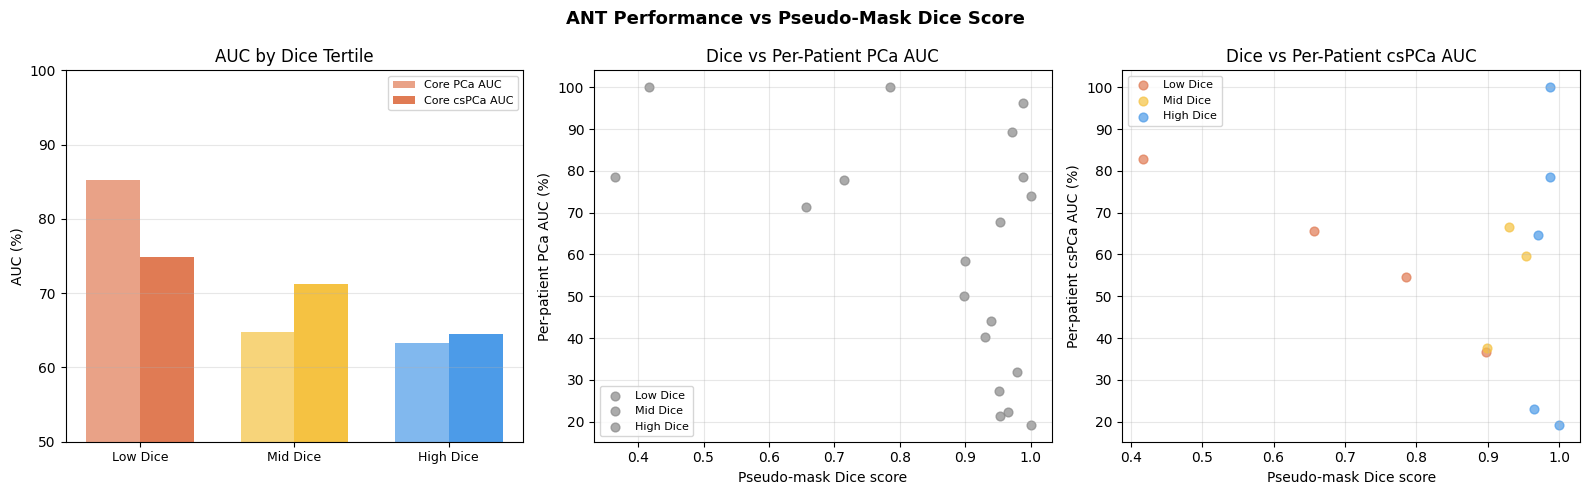

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score


def run_dice_sensitivity_analysis(path_results, path_dice, output_path="dice_sensitivity.pdf"):
    """
    Assess ANT performance sensitivity to pseudo-mask quality (Dice score).

    Parameters
    ----------
    path_results : str — path to ANT results_table CSV
    path_dice    : str — path to dice scores CSV
    output_path  : str — where to save the figure
    """
    df_results = pd.read_csv(path_results, index_col=0)
    df_dice    = pd.read_csv(path_dice)

    # ── One Dice score per patient (mean across cines if multiple) ────────────
    df_dice_patient = (
        df_dice.groupby("case_id")
               .agg(dice=("dice", "mean"))
               .reset_index()
               .rename(columns={"case_id": "patient_id"})
    )

    # ── Merge Dice into results table ─────────────────────────────────────────
    df = df_results.merge(df_dice_patient, on="patient_id", how="inner")
    print(f"Matched {df['patient_id'].nunique()} patients, {len(df)} cores")
    print(f"Dice range: {df['dice'].min():.3f} – {df['dice'].max():.3f}")
    print(f"Dice mean:  {df['dice'].mean():.3f} ± {df['dice'].std():.3f}")

    # ── Stratify patients by Dice tertile ─────────────────────────────────────
    dice_per_patient = df.groupby("patient_id")["dice"].first()
    tertiles         = np.percentile(dice_per_patient, [33, 66])
    print(f"Dice tertiles: {tertiles}")

    def dice_group(d):
        if d <= tertiles[0]:
            return f"Low Dice (≤{tertiles[0]:.2f})"
        elif d <= tertiles[1]:
            return f"Mid Dice ({tertiles[0]:.2f}–{tertiles[1]:.2f})"
        else:
            return f"High Dice (>{tertiles[1]:.2f})"

    df["dice_group"] = df["dice"].apply(dice_group)
    group_order = [
        f"Low Dice (≤{tertiles[0]:.2f})",
        f"Mid Dice ({tertiles[0]:.2f}–{tertiles[1]:.2f})",
        f"High Dice (>{tertiles[1]:.2f})",
    ]

    # ── Compute AUC per Dice group ────────────────────────────────────────────
    score_col  = "average_needle_heatmap_value"
    label_col  = "label"
    cspca_col  = "grade_group"

    rows = []
    for group in group_order:
        sub = df[df["dice_group"] == group].copy()
        sub = sub[~sub[score_col].isna()]

        labels_pca   = sub[label_col].values
        labels_cspca = (sub[cspca_col].values > 2).astype(int)
        scores       = sub[score_col].values
        n_patients   = sub["patient_id"].nunique()
        mean_dice    = sub["dice"].mean()

        auc_pca = auc_cspca = np.nan
        if len(np.unique(labels_pca)) == 2:
            auc_pca   = roc_auc_score(labels_pca,   scores) * 100
        if len(np.unique(labels_cspca)) == 2:
            auc_cspca = roc_auc_score(labels_cspca, scores) * 100

        rows.append({
            "Dice group":       group,
            "n patients":       n_patients,
            "n cores":          len(sub),
            "Mean Dice":        round(mean_dice, 3),
            "Core PCa AUC":     round(auc_pca,   1),
            "Core csPCa AUC":   round(auc_cspca, 1),
        })
        print(f"{group}: n_patients={n_patients}, n_cores={len(sub)}, "
              f"mean_dice={mean_dice:.3f}, AUC_PCa={auc_pca:.1f}, AUC_csPCa={auc_cspca:.1f}")

    summary_df = pd.DataFrame(rows)
    print("\n", summary_df.to_string(index=False))

    # ── Scatter: Dice vs per-patient AUC ─────────────────────────────────────
    patient_stats = []
    for pid, grp in df.groupby("patient_id"):
        grp   = grp[~grp[score_col].isna()]
        dice  = grp["dice"].iloc[0]
        labs  = grp[label_col].values
        cslab = (grp[cspca_col].values > 2).astype(int)
        scrs  = grp[score_col].values

        # AUC only computable if both classes present
        auc_pca = auc_cspca = np.nan
        if len(np.unique(labs)) == 2:
            auc_pca   = roc_auc_score(labs,   scrs) * 100
        if len(np.unique(cslab)) == 2:
            auc_cspca = roc_auc_score(cslab,  scrs) * 100

        patient_stats.append({
            "patient_id": pid,
            "dice":       dice,
            "auc_pca":    auc_pca,
            "auc_cspca":  auc_cspca,
            "dice_group": grp["dice_group"].iloc[0],
        })

    pt_df = pd.DataFrame(patient_stats)

    # ── Plot ──────────────────────────────────────────────────────────────────
    colors = {"Low Dice":  "#E07B54", "Mid Dice": "#F5C242", "High Dice": "#4C9BE8"}

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("ANT Performance vs Pseudo-Mask Dice Score", fontsize=13, fontweight="bold")

    # 1. Bar chart: AUC per Dice tertile
    ax = axes[0]
    x       = np.arange(len(group_order))
    width   = 0.35
    auc_pca_vals   = [r["Core PCa AUC"]   for r in rows]
    auc_cspca_vals = [r["Core csPCa AUC"] for r in rows]
    bar_colors     = [list(colors.values())[i] for i in range(3)]

    ax.bar(x - width/2, auc_pca_vals,   width, label="Core PCa AUC",   color=bar_colors, alpha=0.7)
    ax.bar(x + width/2, auc_cspca_vals, width, label="Core csPCa AUC", color=bar_colors, alpha=1.0)
    ax.set_xticks(x)
    ax.set_xticklabels([g.split(" (")[0] for g in group_order], fontsize=9)
    ax.set_ylabel("AUC (%)")
    ax.set_ylim(50, 100)
    ax.set_title("AUC by Dice Tertile")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

    # 2. Scatter: Dice vs per-patient PCa AUC
    ax = axes[1]
    valid = pt_df.dropna(subset=["auc_pca"])
    for group in group_order:
        sub = valid[valid["dice_group"] == group]
        key = group.split(" (")[0].replace(" Dice", "") + " Dice"
        col = colors.get(group.split(" (")[0] + " Dice", "#888888")
        ax.scatter(sub["dice"], sub["auc_pca"], label=group.split(" (")[0],
                   color=col, alpha=0.7, s=40)
    ax.set_xlabel("Pseudo-mask Dice score")
    ax.set_ylabel("Per-patient PCa AUC (%)")
    ax.set_title("Dice vs Per-Patient PCa AUC")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # 3. Scatter: Dice vs per-patient csPCa AUC
    ax = axes[2]
    valid = pt_df.dropna(subset=["auc_cspca"])
    for group in group_order:
        sub = valid[valid["dice_group"] == group]
        col = list(colors.values())[group_order.index(group)]
        ax.scatter(sub["dice"], sub["auc_cspca"], label=group.split(" (")[0],
                   color=col, alpha=0.7, s=40)
    ax.set_xlabel("Pseudo-mask Dice score")
    ax.set_ylabel("Per-patient csPCa AUC (%)")
    ax.set_title("Dice vs Per-Patient csPCa AUC")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_path, bbox_inches="tight", dpi=150)
    print(f"\nSaved to {output_path}")
    plt.show()

    return summary_df, pt_df


if __name__ == "__main__":
    summary_df, pt_df = run_dice_sensitivity_analysis(
        path_results="/project/6106383/obed/medproj/medAI/logs/statistics_proside_ttt/train_nct_test_optimum/bootstrap_baseDINO_test_ua_UA/test_results_epoch_0000.csv",
        # path_results="/project/6106383/obed/medproj/medAI/logs/statistics_proside_ttt/train_nct_test_optimum/delong_bootstrap_ANT_DINO_test_ua_UA/test_results_epoch_0000.csv",
        path_dice="/project/6106383/obed/medproj/medAI/projects/seg_ttt/dice_scores_ua.csv",
        output_path="dice_basedino_ua_sensitivity.pdf",
    )
    summary_df.to_csv("dice_basedino_ua_sensitivity_summary.csv", index=False)
    pt_df.to_csv("dice_basedino_ua_sensitivity_per_patient.csv", index=False)